<a href="https://colab.research.google.com/github/sgisgeodata/sgis-data-manual/blob/main/%EA%B3%B5%EA%B0%84%EB%B6%84%EC%84%9D%20%EC%82%AC%EB%A1%80/Python/%EB%B6%80%EC%82%B0%EC%8B%9C%20%EC%9D%B8%EA%B5%AC%20%EA%B2%A9%EC%9E%90%EB%B3%84%20%EB%B6%84%EC%84%9D/%EB%B6%80%EC%82%B0%EC%8B%9C_%EC%9D%B8%EA%B5%AC_%EA%B2%A9%EC%9E%90%EB%B3%84_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 부산시 인구 격자별 분석(Python)
- SGIS 자료제공 메뉴에서 내려받은 부산시 경계(bnd_sigungu_21_2025_2Q.shp), 격자 경계(grid_마라_1K.shp, grid_마마_1K.shp), 2024년 격자통계(2024년_인구_마라_1K.csv, 2024년_인구_마마_1K.csv)를 파이썬으로 분석하는 과정을 설명합니다.

- SGIS : https://sgis.mods.go.kr

- GitHub : https://github.com/sgisgeodata/sgis-data-manual

- 분석 내용: https://sgis.mods.go.kr/view/pss/dataBook04

In [1]:
# Git LFS 설치 (LFS: GitHub에서 대용량 파일(shp, tif 등)을 관리하기 위한 도구)
!apt-get -qq install git-lfs

# Git LFS 사용 환경 설정
!git lfs install

# 코랩 환경의 기존 저장소 삭제
!rm -rf sgis-data-manual

# GitHub 저장소 클론(다운로드)
!git clone https://github.com/sgisgeodata/sgis-data-manual.git

# 저장소 폴더로 이동
%cd sgis-data-manual

# Git LFS로 관리되는 실제 파일 다운로드
!git lfs pull

# 원래 디렉터리로 이동
%cd ..

Selecting previously unselected package git-lfs.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Git LFS initialized.
Cloning into 'sgis-data-manual'...
remote: Enumerating objects: 1373, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 1373 (delta 105), reused 79 (delta 38), pack-reused 1169 (from 2)
Receiving objects: 100% (1373/1373), 298.56 MiB | 21.33 MiB/s, done.
Resolving deltas: 100% (569/569), done.
Updating files: 100% (813/813), done.
/content/sgis-data-manual
/content


In [2]:
# 한글 폰 설치
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 75.6 MB/s eta 0:00:00


In [3]:
# 라이브러리 로드
import geopandas as gpd  # 지리정보 파일 읽고 처리
import pandas as pd  # 표 형식 데이터 처리
import matplotlib.pyplot as plt  # 그래프, 지도 등 시각화
import koreanize_matplotlib # 한글 폰트

In [5]:
# 데이터 불러오기
prj_dir = '/content/sgis-data-manual/공간분석 사례/Python/부산시 인구 격자별 분석'

bord_sido = gpd.read_file(prj_dir + '/' + 'bnd_sido_21_2025_2Q.shp')
grid_mara = gpd.read_file(prj_dir + '/' + 'grid_마라_1K.shp')
grid_mama = gpd.read_file(prj_dir + '/' + 'grid_마마_1K.shp')
stat_mara = pd.read_csv(prj_dir + '/' + '2024년_인구_마라_1K.csv', encoding='CP949',
                       names=['BASE_YEAR', 'GRID_CD', 'STAT_CD', 'POP'])
stat_mama = pd.read_csv(prj_dir + '/' + '2024년_인구_마마_1K.csv', encoding='CP949',
                       names=['BASE_YEAR', 'GRID_CD', 'STAT_CD', 'POP'])

In [7]:
grid_merged = pd.concat([grid_mara, grid_mama], ignore_index=True)
stat_merged = pd.concat([stat_mara, stat_mama], ignore_index=True)

In [10]:
print(grid_merged.info())  # 격자 경계 코드(GRID_CD), 지리정보(geometry)로 구성

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   GRID_CD   9551 non-null   object  
 1   geometry  9551 non-null   geometry
dtypes: geometry(1), object(1)
memory usage: 149.4+ KB
None


In [11]:
print(stat_merged.info())  # 기준년도(BASE_YEAR), 격자 경계 코드(GRID_CD),
                           # 통계 코드(STAT_CD), 인구수(POP)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260662 entries, 0 to 260661
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   BASE_YEAR  260662 non-null  int64 
 1   GRID_CD    260662 non-null  object
 2   STAT_CD    260662 non-null  object
 3   POP        260662 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 8.0+ MB
None


In [12]:
print(stat_merged.info())  # 기준년도(BASE_YEAR), 격자 경계 코드(GRID_CD),
                           # 통계 코드(STAT_CD), 인구수(POP)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260662 entries, 0 to 260661
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   BASE_YEAR  260662 non-null  int64 
 1   GRID_CD    260662 non-null  object
 2   STAT_CD    260662 non-null  object
 3   POP        260662 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 8.0+ MB
None


In [13]:
# STAT_CD 열에 있는 고유 값 확인
unique_stat_cd = stat_merged['STAT_CD'].unique()
print(unique_stat_cd)

['in_age_005' 'in_age_006' 'in_age_007' 'in_age_008' 'in_age_011'
 'in_age_012' 'in_age_013' 'in_age_014' 'in_age_015' 'in_age_016'
 'in_age_017' 'in_age_035' 'in_age_036' 'in_age_037' 'in_age_041'
 'in_age_042' 'in_age_043' 'in_age_044' 'in_age_045' 'in_age_046'
 'in_age_047' 'in_age_066' 'in_age_068' 'in_age_071' 'in_age_073'
 'in_age_074' 'in_age_075' 'in_age_076' 'in_age_077' 'to_in_001'
 'to_in_007' 'to_in_008' 'in_age_003' 'in_age_004' 'in_age_009'
 'in_age_010' 'in_age_018' 'in_age_019' 'in_age_020' 'in_age_034'
 'in_age_038' 'in_age_039' 'in_age_040' 'in_age_048' 'in_age_063'
 'in_age_064' 'in_age_070' 'in_age_072' 'in_age_078' 'in_age_079'
 'in_age_080' 'in_age_033' 'in_age_065' 'in_age_069' 'in_age_002'
 'in_age_062' 'in_age_067' 'in_age_032' 'in_age_049' 'in_age_001'
 'in_age_061' 'in_age_031' 'in_age_050' 'in_age_021' 'in_age_081'
 'in_age_051']


In [14]:
# 총인구('to_in_001') 데이터만 필터링
stat_total = stat_merged[stat_merged['STAT_CD'] == 'to_in_001']

In [15]:
# 필터링 후 STAT_CD 고유값 재확인
unique_stat_cd = stat_total['STAT_CD'].unique()
print(unique_stat_cd)

['to_in_001']


In [16]:
stat_total = stat_total[['GRID_CD', 'POP']]

In [17]:
# 부산시 경계와 격자 경계가 교차하는 격자만 선택하기
grid_intersects = grid_merged[grid_merged.geometry.intersects(bord_sido.geometry.union_all())]
grid_intersects = grid_intersects.merge(stat_total, on='GRID_CD', how='left')

In [18]:
# 결합 후 통계값이 없는 구간에 NaN이 들어가 있을 수 있음(결측값 확인)
print(grid_intersects.isna().sum())

GRID_CD       0
geometry      0
POP         238
dtype: int64


In [19]:
# 결측값을 0으로 채우기
grid_intersects['POP'] = grid_intersects['POP'].fillna(0)

In [20]:
# 인구 구간 직접 지정하여 나누기
print(grid_intersects['POP'].min(), grid_intersects['POP'].max())  # 최소값과 최대값 확인

0.0 31259.0


In [21]:
bins = [0, 1000, 5000, 10000, 20000, 32000]  # 적절한 구간 지정
labels = ['0~1000', '1000~5000', '5000~10,000', '10,000~20,000', '20,000~32,000']  # 구간의 라벨


In [22]:
# 각 인구 수에 대해 구간 할당
grid_intersects['POP_BINS'] = pd.cut(grid_intersects['POP'], bins=bins, labels=labels, right=False)
print(grid_intersects.head(100))  # 인구 구간(‘POP_BINS’) 컬럼 추가 확인

   GRID_CD                                           geometry    POP POP_BINS
0   마라1569  POLYGON ((1115000 1669000, 1115000 1670000, 11...    0.0   0~1000
1   마라1668  POLYGON ((1116000 1668000, 1116000 1669000, 11...    0.0   0~1000
2   마라1669  POLYGON ((1116000 1669000, 1116000 1670000, 11...    0.0   0~1000
3   마라1773  POLYGON ((1117000 1673000, 1117000 1674000, 11...    0.0   0~1000
4   마라1774  POLYGON ((1117000 1674000, 1117000 1675000, 11...    0.0   0~1000
..     ...                                                ...    ...      ...
95  마라2384  POLYGON ((1123000 1684000, 1123000 1685000, 11...  148.0   0~1000
96  마라2385  POLYGON ((1123000 1685000, 1123000 1686000, 11...  318.0   0~1000
97  마라2386  POLYGON ((1123000 1686000, 1123000 1687000, 11...    5.0   0~1000
98  마라2475  POLYGON ((1124000 1675000, 1124000 1676000, 11...    0.0   0~1000
99  마라2476  POLYGON ((1124000 1676000, 1124000 1677000, 11...    0.0   0~1000

[100 rows x 4 columns]


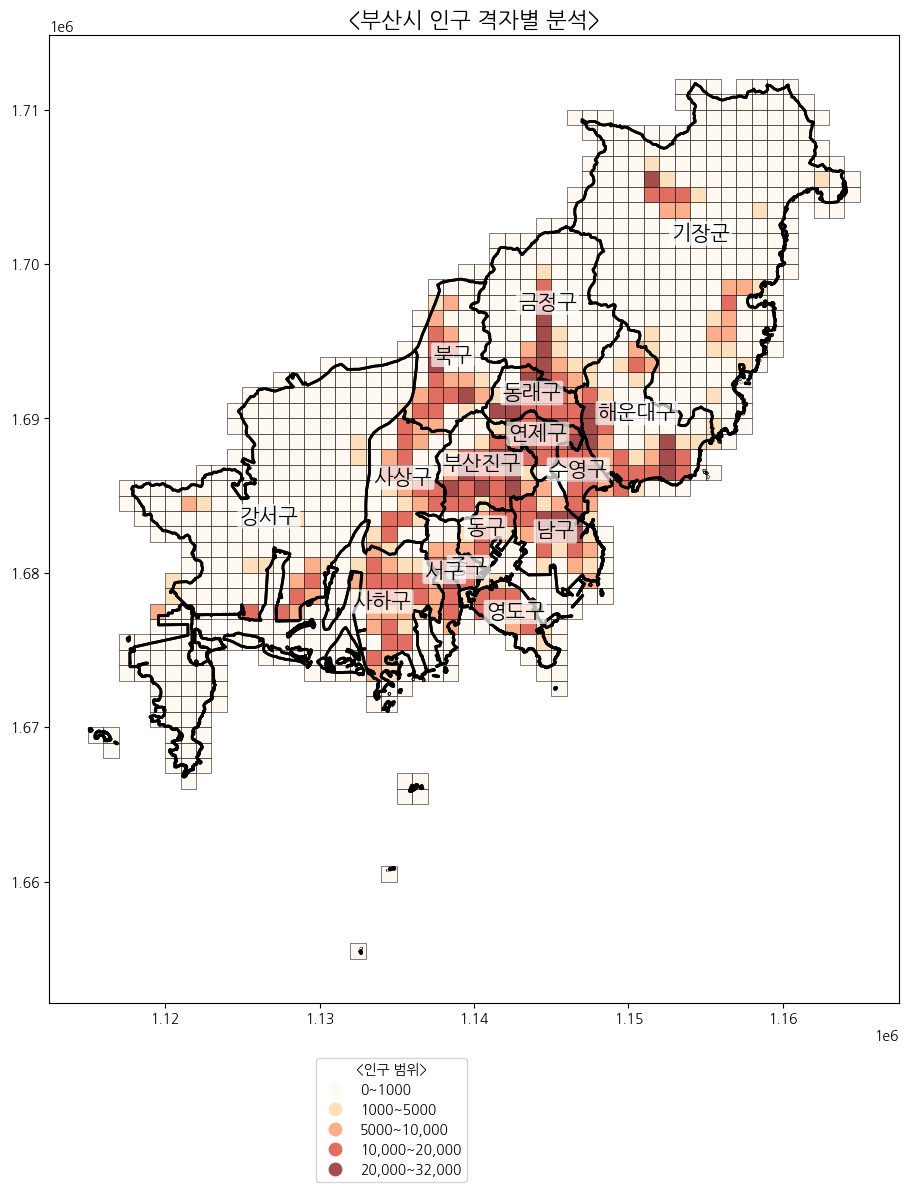

In [23]:
# 시각화 설정(그림과 축 설정)
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 격자 시각화(격자 경계 선은 연하게 설정)
grid_intersects.plot(column='POP_BINS', ax=ax, legend=True, cmap='OrRd',
                     edgecolor='black', linewidth=0.5, alpha=0.7)

# 부산시 경계 추가 (경계선만 보이도록 설정, 배경은 투명)
bord_sido.plot(ax=ax, color='none', edgecolor='black', linewidth=2)

# (추가) 부산시 시군구 경계를 추가하여 명확하게 분석하기
bord_sgg = gpd.read_file(prj_dir + '/' + 'bnd_sigungu_21_2025_2Q.shp')

bord_sgg.plot(ax=ax, color='none', edgecolor='black', linewidth=2)

bord_sgg['centroid'] = bord_sgg.geometry.centroid  # 중심점 계산
for idx, row in bord_sgg.iterrows():
    ax.text(row['centroid'].x, row['centroid'].y, row['SIGUNGU_NM'],
            fontsize=15, ha='center', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.1'))
# (추가 끝)

# 범례 위치 및 제목 설정
ax.get_legend().set_bbox_to_anchor((0.5, -0.05))  # 범례 위치 조정
ax.get_legend().set_title("<인구 범위>")  # 범례 제목 설정
ax.set_title('<부산시 인구 격자별 분석>', fontsize=16) # 지도 제목 설정

# 레이아웃 조정 및 출력
plt.tight_layout()  # 그래프 레이아웃이 겹치지 않도록 자동 조정
plt.savefig(prj_dir + '/' + '부산시 인구 격자별 분석 지도.png')
plt.show()  # 시각화 결과 화면에 출력